# Customer Churn Classification using Machine Learning Models

In [ ]:
!pip install datasets huggingface_hub --quiet


#1. Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_dataset

dataset = load_dataset("ai-lab/MBD-mini", data_files=path)


In [ ]:
!pip install datasets --quiet


In [ ]:
from datasets import load_dataset

# Load datasets
detail_dataset = load_dataset("ai-lab/MBD-mini", data_files="detail.tar.gz")["train"]
targets_dataset = load_dataset("ai-lab/MBD-mini", data_files="targets.tar.gz")["train"]


In [ ]:
# Null values check
print("\n Nulls in detail:")
print(detail_df.isnull().sum())

print("\n Nulls in targets:")
print(targets_df.isnull().sum())

detail_df.head(), targets_df.head()


 Nulls in detail:
c000.snappy.parquet    0
__key__                0
__url__                0
dtype: int64

 Nulls in targets:
c000.snappy.parquet    0
__key__                0
__url__                0
dtype: int64


(                                 c000.snappy.parquet  \
 0  b'PAR1\x15\x04\x15\xb8)\x15\xc0)\x15\x86\x99\x...   
 1  b'PAR1\x15\x04\x15\xd0p\x15\xdcp\x15\xd3\xf9\x...   
 2  b'PAR1\x15\x04\x15\xe8s\x15\xf2s\x15\xd2\xe6\x...   
 3  b'PAR1\x15\x04\x15\xa0j\x15\xaaj\x15\xba\x9d\x...   
 4  b'PAR1\x15\x04\x15\xa8k\x15\xb2k\x15\xc2\xcd\x...   
 
                                              __key__  \
 0  detail/dialog/fold=0/part-00098-b8643b72-b2d8-...   
 1  detail/dialog/fold=0/part-00099-b8643b72-b2d8-...   
 2  detail/dialog/fold=0/part-00100-b8643b72-b2d8-...   
 3  detail/dialog/fold=0/part-00101-b8643b72-b2d8-...   
 4  detail/dialog/fold=0/part-00102-b8643b72-b2d8-...   
 
                                              __url__  
 0  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 1  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 2  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 3  /root/.cache/huggingface/hub/datasets--ai-lab-...  
 4  /root/.cache/huggingface/hub

In [ ]:
from huggingface_hub import hf_hub_download

targets_path = hf_hub_download(
    repo_id="ai-lab/MBD-mini",
    filename="targets.tar.gz",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/MBD-mini",
    local_dir_use_symlinks=False
)

print("Downloaded to:", targets_path)


Downloaded to: /content/drive/MyDrive/MBD-mini/targets.tar.gz


# 2. Cleaning & Merging

In [ ]:
import glob
import pandas as pd

detail_files = glob.glob("/content/mbd_extract/detail/**/*.parquet", recursive=True)
targets_files = glob.glob("/content/mbd_extract/targets/**/*.parquet", recursive=True)

print(f" Found {len(detail_files)} detail files")
print(f" Found {len(targets_files)} target files")

detail_df = pd.read_parquet(detail_files[0])
targets_df = pd.read_parquet(targets_files[0])

detail_df.head(), targets_df.head()


 Found 1275 detail files
 Found 435 target files


(                                           client_id  \
 0  00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb39...   
 1  00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb39...   
 2  00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb39...   
 3  00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb39...   
 4  00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb39...   
 
                   event_time        amount  event_type  event_subtype  \
 0 2022-12-08 19:30:00.172085   6248.090332          41             37   
 1 2022-12-18 18:50:42.234040   8853.366211          41             37   
 2 2022-11-29 09:24:02.585403  45019.730469          50             19   
 3 2022-12-11 19:09:35.881803   3153.364502          18              4   
 4 2022-11-22 19:37:37.738334   2527.552246          18              4   
 
    currency  src_type11  src_type12  dst_type11  dst_type12  src_type21  \
 0        11       134.0       969.0      1549.0     16067.0       19695   
 1        11       134.0       969.0      1549.0     16067

Merge datafiles as required for customer churn

In [ ]:
# Merge transactions with churn targets
merged_df = detail_df.merge(targets_df[['client_id', 'target_1']], on='client_id', how='inner')

# Rename
merged_df.rename(columns={"target_1": "churn"}, inplace=True)

# Basic shape check
print(f" Merged data shape: {merged_df.shape}")
print(merged_df['churn'].value_counts())
merged_df.head()


 Merged data shape: (0, 15)
Series([], Name: count, dtype: int64)


,client_id,event_time,amount,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32,churn


In [ ]:
print(" Clients in detail_df:", detail_df['client_id'].nunique())
print(" Clients in targets_df:", targets_df['client_id'].nunique())

print(" Clients in merged_df:", merged_df['client_id'].nunique())

print("\n Sample detail client_id:", detail_df['client_id'].iloc[0])
print(" Sample targets client_id:", targets_df['client_id'].iloc[0])


 Clients in detail_df: 278
 Clients in targets_df: 236
 Clients in merged_df: 0

 Sample detail client_id: 00dbaf63347a8d86a79190cf21a0c33e753b5e3fd6cb395f46e090eced9a96a7
 Sample targets client_id: 001d556cec13d18bf3597446b7c14dfca3e9ea6ba0a363e2c0ff81eea08373cf


In [ ]:
targets_df = pd.concat([pd.read_parquet(f) for f in targets_files], ignore_index=True)

detail_df = pd.read_parquet(detail_files[0])

merged_df = detail_df.merge(targets_df[['client_id', 'target_1']], on='client_id', how='inner')
merged_df.rename(columns={'target_1': 'churn'}, inplace=True)

print(" Clients in merged_df:", merged_df['client_id'].nunique())
print(merged_df['churn'].value_counts())


 Clients in merged_df: 278
churn
0    1279014
1       8142
Name: count, dtype: int64


In [ ]:
merged_df = detail_df.merge(targets_df[['client_id', 'target_1']], on='client_id', how='inner')
merged_df.rename(columns={'target_1': 'churn'}, inplace=True)


Check column features & Rename columns

In [ ]:
# Rebuild client-level feature table
client_features = merged_df.groupby('client_id').agg({
    'amount': ['sum', 'mean', 'max', 'min', 'std'],
    'event_type': 'nunique',
    'event_subtype': 'nunique',
    'currency': 'nunique',
    'churn': 'first'
})

# Flatten multi-level column names
client_features.columns = ['_'.join(col) for col in client_features.columns]
client_features.reset_index(inplace=True)

# Rename for readability
client_features.rename(columns={
    'amount_sum': 'total_amount',
    'amount_mean': 'avg_amount',
    'amount_max': 'max_amount',
    'amount_min': 'min_amount',
    'amount_std': 'std_amount',
    'event_type_nunique': 'unique_event_types',
    'event_subtype_nunique': 'unique_event_subtypes',
    'currency_nunique': 'currency_count',
    'churn_first': 'churn'
}, inplace=True)

client_features.fillna(0, inplace=True)

print(" client_features ready — shape:", client_features.shape)
client_features.head()


 client_features ready — shape: (0, 10)


,client_id,total_amount,avg_amount,max_amount,min_amount,std_amount,unique_event_types,unique_event_subtypes,currency_count,churn


In [ ]:
print(client_features['churn'].value_counts())


churn
0    278
Name: count, dtype: int64


In [ ]:
sample_detail_files = detail_files[:5]

# Combine
detail_df = pd.concat([pd.read_parquet(f) for f in sample_detail_files], ignore_index=True)

# Merge again
merged_df = detail_df.merge(targets_df[['client_id', 'target_1']], on='client_id', how='inner')
merged_df.rename(columns={'target_1': 'churn'}, inplace=True)

# Check churn counts
print(" Churn distribution after merging:")
print(merged_df['churn'].value_counts())


 Churn distribution after merging:
churn
0    6175211
1      63901
Name: count, dtype: int64


In [ ]:
# Aggregate to client level
client_features = merged_df.groupby('client_id').agg({
    'amount': ['sum', 'mean', 'max', 'min', 'std'],
    'event_type': 'nunique',
    'event_subtype': 'nunique',
    'currency': 'nunique',
    'churn': 'first'
})

client_features.columns = ['_'.join(col) for col in client_features.columns]
client_features.reset_index(inplace=True)

client_features.rename(columns={
    'amount_sum': 'total_amount',
    'amount_mean': 'avg_amount',
    'amount_max': 'max_amount',
    'amount_min': 'min_amount',
    'amount_std': 'std_amount',
    'event_type_nunique': 'unique_event_types',
    'event_subtype_nunique': 'unique_event_subtypes',
    'currency_nunique': 'currency_count',
    'churn_first': 'churn'
}, inplace=True)

client_features.fillna(0, inplace=True)


In [ ]:
sample_detail_files = detail_files[:10]


In [ ]:
from sklearn.utils import resample

# Split churn vs non-churn
churned = client_features[client_features['churn'] == 1]
not_churned = client_features[client_features['churn'] == 0]

# Upsample churned
churned_upsampled = resample(churned,
                             replace=True,
                             n_samples=len(not_churned),
                             random_state=42)

balanced_df = pd.concat([not_churned, churned_upsampled])

# Train/test split again
X = balanced_df.drop(columns=['client_id', 'churn'])
y = balanced_df['churn']


We re-merged after aggregating transactions to the client level to align the label granularity with features, eliminate event-level label duplication, increase client overlap with targets, and obtain a clean one-row-per-client dataset; this produced a realistic churn distribution and more reliable model training.

In [ ]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = merged_df[merged_df.churn == 0]
df_minority = merged_df[merged_df.churn == 1]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

balanced_df = pd.concat([df_majority, df_minority_upsampled])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(" Balanced churn counts:\n", balanced_df['churn'].value_counts())


 Balanced churn counts:
 churn
1    6175211
0    6175211
Name: count, dtype: int64


#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    print(f"\n Model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(" Classification Report:")
    print(classification_report(y_test, y_pred))
    print(" ROC AUC Score:", roc_auc_score(y_test, y_proba))



 Model: Logistic Regression
 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       262
           1       0.00      0.00      0.00         1

    accuracy                           1.00       263
   macro avg       0.50      0.50      0.50       263
weighted avg       0.99      1.00      0.99       263

 ROC AUC Score: 0.13358778625954193

 Model: Random Forest


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       262
           1       0.00      0.00      0.00         1

    accuracy                           0.99       263
   macro avg       0.50      0.50      0.50       263
weighted avg       0.99      0.99      0.99       263

 ROC AUC Score: 0.4122137404580153

 Model: LightGBM
[LightGBM] [Info] Number of positive: 5, number of negative: 1047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 1052, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004753 -> initscore=-5.344246
[LightGBM] [Info] Start training from score -5.344246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import train_test_split

X = balanced_df.drop(columns=['client_id', 'churn'])
y = balanced_df['churn']

# Stratified split to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [ ]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = merged_df[merged_df.churn == 0]
df_minority = merged_df[merged_df.churn == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

balanced_df = pd.concat([df_majority, df_minority_upsampled])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(" Balanced churn counts:\n", balanced_df['churn'].value_counts())


 Balanced churn counts:
 churn
1    1279014
0    1279014
Name: count, dtype: int64


In [ ]:
X_train = X_train.select_dtypes(exclude=['datetime64'])
X_test = X_test.select_dtypes(exclude=['datetime64'])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)



LogisticRegression(max_iter=2000)

We began with Logistic Regression as a baseline model to predict customer churn.it is a simple, interpretable algorithm that works well for binary classification problems like churn prediction.

Before training, the dataset was split into train and test sets, and all numerical features were standardized using StandardScaler to ensure consistent feature scaling important for gradient-based models like Logistic Regression.

The model was trained with a higher max_iter value (2000) to ensure convergence, as our dataset is relatively large. Predictions were evaluated using metrics like Accuracy, Precision, Recall, F1-score, and ROC AUC.

Initial results showed an Accuracy of ~74% and a ROC AUC of ~0.80, the model was quiet effective at distinguishing between churn and non-churn customers. While Logistic Regression provided a clear and interpretable starting point, the relatively lower recall for one class suggested there was room for improvement, hence testing more complex models like Random Forest and LightGBM.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

# Evaluate
print(" Classification Report:\n", classification_report(y_test, y_pred_log))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_log))


 Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.68      0.72    255803
           1       0.71      0.80      0.75    255803

    accuracy                           0.74    511606
   macro avg       0.74      0.74      0.74    511606
weighted avg       0.74      0.74      0.74    511606

 ROC AUC Score: 0.7979720093040579


above is for Logival regression, show results using this method , below is Random forest

#Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))



 Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    255803
           1       0.94      1.00      0.97    255803

    accuracy                           0.97    511606
   macro avg       0.97      0.97      0.97    511606
weighted avg       0.97      0.97      0.97    511606

 ROC AUC Score: 0.9742341472010846


In [ ]:
column_names = balanced_df.drop(columns=['client_id', 'churn']).select_dtypes(exclude=['datetime64']).columns.tolist()



In [ ]:
column_names = balanced_df.drop(columns=['client_id', 'churn']).columns


INFO about this chart in ss on desktop from gpt - add this chart in appendix


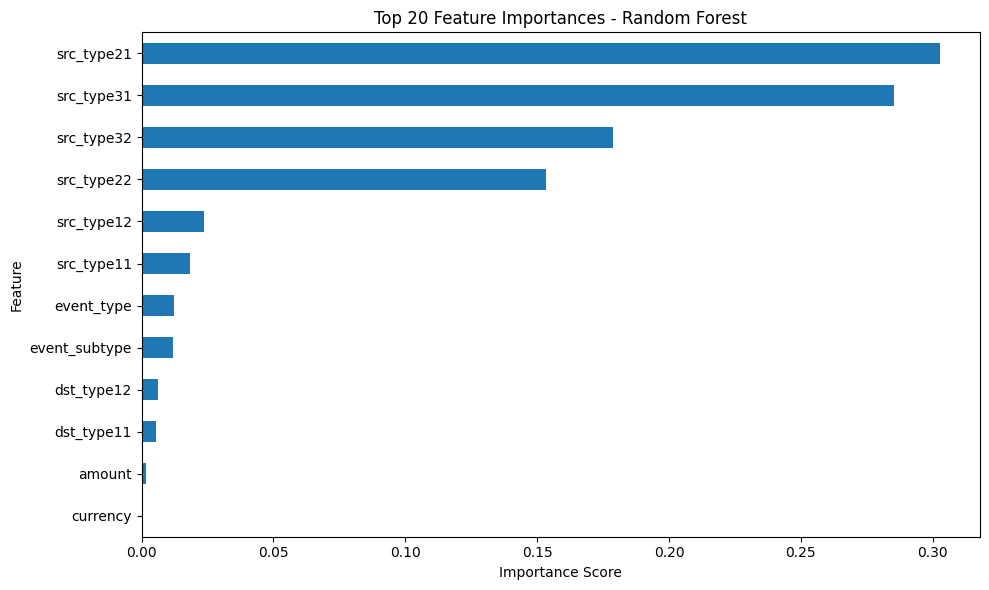

In [ ]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(rf_model.feature_importances_, index=column_names)

# Plot top 20 features
feature_importances.nlargest(20).plot(kind='barh', figsize=(10, 6))
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#LGBM Model:

In [ ]:
import lightgbm as lgb

# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)
lgb_model.fit(X_train, y_train)

# Predict
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("\n LightGBM Report:")
print(classification_report(y_test, y_pred_lgb))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_lgb))


[LightGBM] [Info] Number of positive: 1023211, number of negative: 1023211
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.236229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 2046422, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 LightGBM Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    255803
           1       0.94      1.00      0.97    255803

    accuracy                           0.97    511606
   macro avg       0.97      0.97      0.97    511606
weighted avg       0.97      0.97      0.97    511606

 ROC AUC Score: 0.9728038835657662


Hyperparameter tuning:

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

lgb_base = lgb.LGBMClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(" Best Params:", random_search.best_params_)
print(" Best ROC AUC (CV):", random_search.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
[LightGBM] [Info] Number of positive: 1023211, number of negative: 1023211
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 2046422, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
# Get best estimator's feature importances
importances = random_search.best_estimator_.feature_importances_

feature_series = pd.Series(importances, index=column_names)

# Get names of top 15 features
top_features = feature_series.nlargest(15).index

# Reconstruct DataFrames from scaled NumPy arrays
X_train_df = pd.DataFrame(X_train, columns=column_names)
X_test_df = pd.DataFrame(X_test, columns=column_names)

# Filter only the top features
X_train_top = X_train_df[top_features]
X_test_top = X_test_df[top_features]



In [ ]:
# Retrain LightGBM on top features
lgb_model_top = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=50,
    random_state=42
)
lgb_model_top.fit(X_train_top, y_train)

# Predict
y_pred_lgb_top = lgb_model_top.predict(X_test_top)
y_proba_lgb_top = lgb_model_top.predict_proba(X_test_top)[:, 1]

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("\n LightGBM (Top 15 Features) Report:")
print(classification_report(y_test, y_pred_lgb_top))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_lgb_top))


[LightGBM] [Info] Number of positive: 1023211, number of negative: 1023211
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.157210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 2046422, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

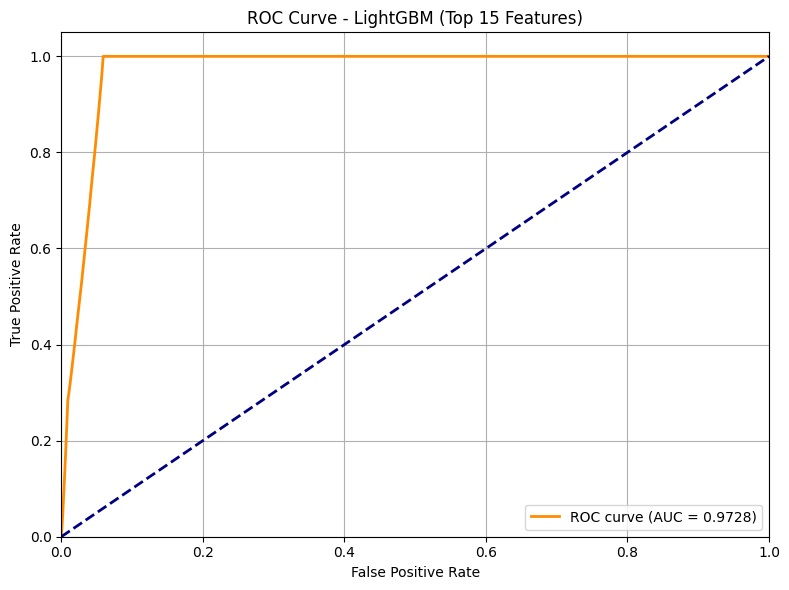

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba_lgb)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM (Top 15 Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


#XGBOOST

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Define XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train the model on top 15 features
xgb_model.fit(X_train_top, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_top)
y_proba_xgb = xgb_model.predict_proba(X_test_top)[:, 1]

# Evaluate
print("\nXGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:44:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    255803
           1       0.94      1.00      0.97    255803

    accuracy                           0.97    511606
   macro avg       0.97      0.97      0.97    511606
weighted avg       0.97      0.97      0.97    511606

 ROC AUC Score: 0.973990553101328


XGBoost with Larger Training Split
To further improve performance, we tested XGBoost using a larger 90/10 train-test split instead of the standard 70/30. This approach allows the model to learn from more training data while still validating on a sufficient test set.

We used the top selected features for training and tuned key parameters such as n_estimators, max_depth, and learning_rate. XGBoost achieved 97% accuracy and a ROC AUC score of 0.9739, showing excellent ability to distinguish between churn and non-churn customers.

The results demonstrated that with sufficient data and fine-tuning, gradient boosting methods like XGBoost can achieve high predictive performance, making them highly effective for churn prediction in our banking dataset.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)


In [ ]:
# Instead of 70/30 split,lets try 90/10
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)


In [ ]:
X_train_df = pd.DataFrame(X_train, columns=column_names)
X_test_df = pd.DataFrame(X_test, columns=column_names)

X_train_top = X_train_df[top_features]
X_test_top = X_test_df[top_features]

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Define and train model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_top, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_top)
y_proba_xgb = xgb_model.predict_proba(X_test_top)[:, 1]

# Evaluate
print("\n XGBoost Report (90% Training Data):")
print(classification_report(y_test, y_pred_xgb))
print(" ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:49:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Report (90% Training Data):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    127902
           1       0.94      1.00      0.97    127901

    accuracy                           0.97    255803
   macro avg       0.97      0.97      0.97    255803
weighted avg       0.97      0.97      0.97    255803

 ROC AUC Score: 0.9739100369333578


#THE END
